In [ ]:
# 01 WorldCover Processing

## Purpose
Prepare and inspect ESA WorldCover data for Nigeria as the first deployment-site data layer.

## Inputs
- ESA WorldCover 2021 GeoTIFF tiles for Nigeria
- Nigeria ADM0 boundary from geoBoundaries

## Main processing steps
- Locate all ESA WorldCover raster tiles
- Inspect raster metadata and land-cover classes
- Merge tiles into one national mosaic
- Validate the mosaic and class values
- Test clipping the full 10 m mosaic to Nigeria

## Important note
Full-resolution clipping of the 10 m mosaic to Nigeria using `rasterio.mask` required more than 15 GB RAM and was not feasible on the local machine. Therefore, the workflow was changed to a memory-aware approach in Notebook 2, where 5 km land-cover fractions are calculated directly from raster windows instead of loading the full clipped raster into memory.

## Outputs
- `data/processed/nigeria_worldcover_2021_mosaic.tif`
- Documentation of memory limitation and workflow adjustment

In [1]:
from pathlib import Path
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rasterio.plot import show

print("Libraries loaded.")

Libraries loaded.


In [2]:
raw_data_dir = Path("../data/raw")

tif_files = list(raw_data_dir.rglob("*.tif"))

print(f"Number of GeoTIFF files found: {len(tif_files)}")

for file in tif_files[:5]:
    print(file)

Number of GeoTIFF files found: 32
..\data\raw\terrascope_download_20260623_115214\WORLDCOVER\ESA_WORLDCOVER_10M_2021_V200\MAP\ESA_WorldCover_10m_2021_v200_N03E000_Map\ESA_WorldCover_10m_2021_v200_N03E000_Map.tif
..\data\raw\terrascope_download_20260623_115214\WORLDCOVER\ESA_WORLDCOVER_10M_2021_V200\MAP\ESA_WorldCover_10m_2021_v200_N03E003_Map\ESA_WorldCover_10m_2021_v200_N03E003_Map.tif
..\data\raw\terrascope_download_20260623_115214\WORLDCOVER\ESA_WORLDCOVER_10M_2021_V200\MAP\ESA_WorldCover_10m_2021_v200_N03E006_Map\ESA_WorldCover_10m_2021_v200_N03E006_Map.tif
..\data\raw\terrascope_download_20260623_115214\WORLDCOVER\ESA_WORLDCOVER_10M_2021_V200\MAP\ESA_WorldCover_10m_2021_v200_N03E009_Map\ESA_WorldCover_10m_2021_v200_N03E009_Map.tif
..\data\raw\terrascope_download_20260623_115214\WORLDCOVER\ESA_WORLDCOVER_10M_2021_V200\MAP\ESA_WorldCover_10m_2021_v200_N03E012_Map\ESA_WorldCover_10m_2021_v200_N03E012_Map.tif


In [3]:
first_tile = tif_files[0]

with rasterio.open(first_tile) as src:
    print("File:", first_tile.name)
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("Width:", src.width)
    print("Height:", src.height)
    print("Bounds:", src.bounds)
    print("Number of bands:", src.count)

File: ESA_WorldCover_10m_2021_v200_N03E000_Map.tif
CRS: EPSG:4326
Resolution: (8.333333333333333e-05, 8.333333333333333e-05)
Width: 36000
Height: 36000
Bounds: BoundingBox(left=0.0, bottom=3.0, right=3.0, top=6.0)
Number of bands: 1


In [4]:
with rasterio.open(first_tile) as src:
    data = src.read(1)
    unique_values = np.unique(data)

print("Unique class values in first tile:")
print(unique_values)

C:\Users\AyaChguiri\AppData\Local\Temp\ipykernel_27040\2867007767.py:2: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  data = src.read(1)


Unique class values in first tile:
[ 0 10 20 30 40 50 60 80 90 95]


In [5]:
from rasterio.merge import merge
from rasterio.enums import Resampling

print("Mosaic tools loaded.")

Mosaic tools loaded.


In [6]:
src_files_to_mosaic = []

for tif in tif_files:
    src = rasterio.open(tif)
    src_files_to_mosaic.append(src)

print(f"Opened {len(src_files_to_mosaic)} raster tiles.")

Opened 32 raster tiles.


In [7]:
mosaic, mosaic_transform = merge(src_files_to_mosaic)

print("Mosaic created.")
print("Mosaic shape:", mosaic.shape)

Mosaic created.
Mosaic shape: (1, 144000, 288000)


In [8]:
processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

mosaic_path = processed_dir / "nigeria_worldcover_2021_mosaic.tif"

# Use metadata from first tile
out_meta = src_files_to_mosaic[0].meta.copy()

out_meta.update({
    "driver": "GTiff",
    "height": mosaic.shape[1],
    "width": mosaic.shape[2],
    "transform": mosaic_transform,
    "count": 1,
    "compress": "lzw"
})

with rasterio.open(mosaic_path, "w", **out_meta) as dest:
    dest.write(mosaic)

print(f"Mosaic saved to: {mosaic_path}")

Mosaic saved to: ..\data\processed\nigeria_worldcover_2021_mosaic.tif


In [9]:
for src in src_files_to_mosaic:
    src.close()

print("All raster files closed.")

All raster files closed.


In [10]:
with rasterio.open(mosaic_path) as src:
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("Width:", src.width)
    print("Height:", src.height)
    print("Bounds:", src.bounds)
    print("Bands:", src.count)

CRS: EPSG:4326
Resolution: (8.333333333333333e-05, 8.333333333333333e-05)
Width: 288000
Height: 144000
Bounds: BoundingBox(left=-3.0, bottom=3.0, right=21.0, top=15.0)
Bands: 1


In [12]:
from rasterio.windows import Window

unique_values = set()

with rasterio.open(mosaic_path) as src:
    for ji, window in src.block_windows(1):
        block = src.read(1, window=window)
        unique_values.update(np.unique(block).tolist())

print("Unique class values in full mosaic:")
print(sorted(unique_values))

C:\Users\AyaChguiri\AppData\Local\Temp\ipykernel_27040\2857173319.py:7: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  block = src.read(1, window=window)


Unique class values in full mosaic:
[0, 10, 20, 30, 40, 50, 60, 80, 90, 95]


C:\Users\AyaChguiri\AppData\Local\Temp\ipykernel_27040\1988671877.py:2: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  preview = src.read(


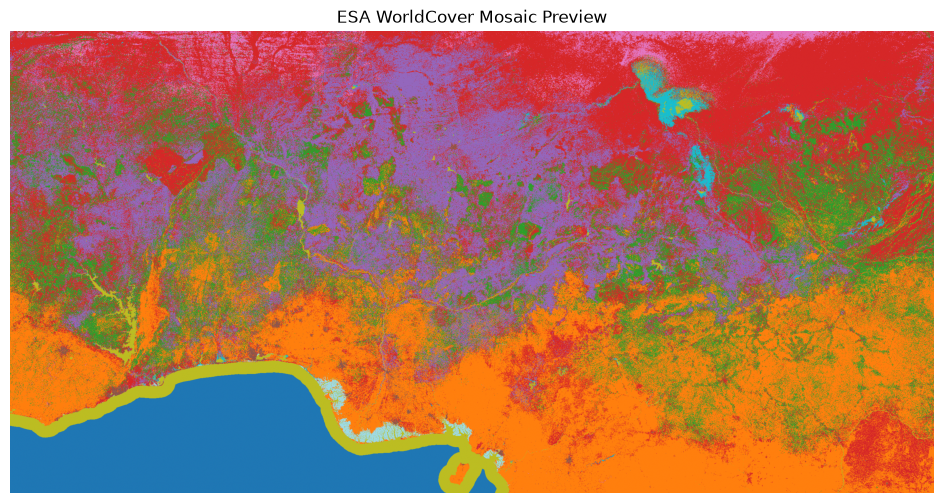

In [13]:
with rasterio.open(mosaic_path) as src:
    preview = src.read(
        1,
        out_shape=(1, src.height // 100, src.width // 100)
    )

plt.figure(figsize=(12, 6))
plt.imshow(preview, cmap="tab20")
plt.title("ESA WorldCover Mosaic Preview")
plt.axis("off")
plt.show()

In [14]:
import geopandas as gpd
from rasterio.mask import mask

print("Boundary and clipping tools loaded.")

Boundary and clipping tools loaded.


In [17]:
boundary_path = boundary_files[0]

nigeria_boundary = gpd.read_file(boundary_path)

print("Boundary loaded from:")
print(boundary_path)

print("\nCRS:")
print(nigeria_boundary.crs)

print("\nNumber of polygons:")
print(len(nigeria_boundary))

nigeria_boundary.head()

Boundary loaded from:
..\data\raw\boundaries\geoBoundaries-NGA-ADM0_simplified.geojson

CRS:
EPSG:4326

Number of polygons:
1


,shapeName,shapeISO,shapeID,shapeGroup,shapeType,geometry
0,the Federal Republic of Nigeria,NGA,39225661B33378512450279,NGA,ADM0,"POLYGON ((5.67705 13.82055, 5.63161 13.83633, ..."


In [18]:
with rasterio.open(mosaic_path) as src:

    nigeria_boundary = nigeria_boundary.to_crs(src.crs)

    clipped_image, clipped_transform = mask(
        src,
        nigeria_boundary.geometry,
        crop=True,
        nodata=0
    )

    clipped_meta = src.meta.copy()

print("Mosaic clipped to Nigeria.")

MemoryError: Unable to allocate 15.5 GiB for an array with shape (1, 115387, 143825) and data type uint8

In [ ]:
## Note: Full-resolution clipping attempt Clipping the full 10 m mosaic to Nigeria using rasterio.mask required more than 15 GB RAM, so the workflow is changed to chunk-based processing. The 5 km fraction table will be calculated directly from the raster tiles/windows without loading the full raster into memory.